![image info](https://user-images.githubusercontent.com/91945811/146929832-e78ff1f4-2739-41b1-acd3-019a39b6a42c.png)

# Airbnb Amsterdam: Feature Engineering Tutorial

Wir verwenden Airbnbn Daten für Amsterdam aus: [airbnb](https://insideairbnb.com/get-the-data/)

Die Daten sind bereits zusammengefasst.

Siehe auch: 
[Visualisierungen](https://insideairbnb.com/amsterdam/)

In [3]:
# Airbnb Amsterdam: Feature Engineering Tutorial

# -----------------------------
# 1. Imports & Daten einlesen
# -----------------------------

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Zusätzliche Importe für erweiterte Transformationen
from sklearn.preprocessing import LabelEncoder

# Setup
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Daten laden
df = pd.read_csv("listings.csv")

In [4]:
display(df)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,2818,Quiet Garden View Room & Super Fast Wi-Fi,3159,Daniel,NaN,Oostelijk Havengebied - Indische Buurt,52.364350,4.943580,Private room,66.0,3,398,2025-01-03,2.05,1,10,31,0363 5F3A 5684 6750 D14D
1,27886,"Romantic, stylish B&B houseboat in canal district",97647,Flip,NaN,Centrum-West,52.387610,4.891880,Private room,NaN,3,294,2025-02-17,1.84,1,88,27,0363 974D 4986 7411 88D8
2,28871,Comfortable double room,124245,Edwin,NaN,Centrum-West,52.367750,4.890920,Private room,75.0,2,677,2025-02-28,3.83,2,84,94,0363 607B EA74 0BD8 2F6F
3,29051,Comfortable single room,124245,Edwin,NaN,Centrum-Oost,52.365840,4.891110,Private room,59.0,2,794,2025-03-02,4.67,2,84,85,0363 607B EA74 0BD8 2F6F
4,44391,Quiet 2-bedroom Amsterdam city centre apartment,194779,Jan,NaN,Centrum-Oost,52.371680,4.914710,Entire home/apt,NaN,3,42,2022-08-20,0.24,1,0,0,0363 E76E F06A C1DD 172C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10070,1366545843850455084,Spacious luxury apartment in City Center,681505793,Frits,NaN,Centrum-Oost,52.363930,4.890370,Entire home/apt,355.0,2,0,NaN,NaN,1,58,0,NaN
10071,1366681723229796790,Cozy appartment in Amsterdam,61554931,Thibault,NaN,De Baarsjes - Oud-West,52.370945,4.865289,Entire home/apt,144.0,1,0,NaN,NaN,1,27,0,036393296596BFB49A0C
10072,1366705754236778230,Bright 1BR Apt w/ 2 Balconies,381452106,Thaiane,NaN,Slotervaart,52.355660,4.833230,Entire home/apt,138.0,2,0,NaN,NaN,1,102,0,0363 EC10 6906 2842 3571
10073,1367343921692027564,Ko l k private mini studio,449825081,Dario,NaN,Centrum-West,52.375430,4.894620,Entire home/apt,126.0,1,0,NaN,NaN,5,5,0,ABCD1234AB1289EFA0F9


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10075 entries, 0 to 10074
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              10075 non-null  int64  
 1   name                            10075 non-null  object 
 2   host_id                         10075 non-null  int64  
 3   host_name                       10058 non-null  object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   10075 non-null  object 
 6   latitude                        10075 non-null  float64
 7   longitude                       10075 non-null  float64
 8   room_type                       10075 non-null  object 
 9   price                           5911 non-null   float64
 10  minimum_nights                  10075 non-null  int64  
 11  number_of_reviews               10075 non-null  int64  
 12  last_review                     

In [6]:
# -----------------------------
# Fehlende Werte analysieren
# -----------------------------
missing = df.isnull().sum().sort_values(ascending=False)
print("\nFehlende Werte in jeder Spalte:\n", missing)


Fehlende Werte in jeder Spalte:
 neighbourhood_group               10075
price                              4164
reviews_per_month                  1131
last_review                        1131
license                             127
host_name                            17
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
name                                  0
minimum_nights                        0
number_of_reviews                     0
host_id                               0
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
id                                    0
dtype: int64


### Überblick zum neuen Datensatz

Der Datensatz enthält **10.075 Einträge** und **18 Spalten**, wobei die folgenden Merkmale besonders hervorzuheben sind:

- **`price`** (Preis pro Nacht) – Enthält fehlende Werte (ca. 40% fehlen).
- **`reviews_per_month`** – Häufigkeit der Bewertungen pro Monat (teils fehlend).
- **`last_review`** – Letztes Bewertungsdatum (teils fehlend).
- **`minimum_nights`** – Mindestanzahl der Nächte.
- **`number_of_reviews`** – Gesamtzahl der Bewertungen.
- **`neighbourhood_group`** – Eine Spalte mit nur `NaN`-Werten und daher zu löschen.

---

## Schritte für **Feature Engineering**: Auswahl, Extraktion, Transformation und Erstellung von Features

### **1. Feature Selection (Auswahl)**

Ziel ist es, **irrelevante oder redundante** Features zu eliminieren. In diesem Fall:
- **`neighbourhood_group`** hat nur `NaN`-Werte und wird daher **entfernt**.
- **`id`, `host_id`, `host_name`, `license`**: Diese sind aus Analysetests oder zur Vorhersage von Preisen nicht direkt relevant und können in vielen Fällen ebenfalls weggelassen werden.
- **`last_review`** ist eine Datumspalte und sollte entsprechend in Datetime umgewandelt werden

In [9]:
# -----------------------------
# 2. Überblick & Bereinigung
# -----------------------------

# Unnötige Spalte entfernen
df.drop(columns=["neighbourhood_group"], inplace=True)

In [10]:
# Fehlende Preise droppen (für Vorhersage nicht verwendbar)
df = df[df["price"].notnull()]

In [11]:
# last_review zu datetime
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

In [12]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,5.911000e+03,5.911000e+03,5911.000000,5911.000000,5911.000000,5911.000000,5911.000000,5181,5181.000000,5911.000000,5911.000000,5911.000000
mean,5.834334e+17,1.425754e+08,52.366880,4.889372,265.115716,3.918626,62.861445,2024-09-03 08:39:11.360741120,1.316427,2.128912,135.943157,13.186094
min,2.818000e+03,3.159000e+03,52.291220,4.755870,10.000000,1.000000,0.000000,2016-05-07 00:00:00,0.010000,1.000000,0.000000,0.000000
25%,2.829221e+07,1.376450e+07,52.355868,4.866425,145.000000,2.000000,3.000000,2024-08-18 00:00:00,0.310000,1.000000,29.000000,1.000000
50%,7.101615e+17,5.233236e+07,52.366040,4.887570,209.000000,2.000000,11.000000,2024-11-28 00:00:00,0.550000,1.000000,96.000000,4.000000
75%,1.096901e+18,2.213747e+08,52.376667,4.906885,300.000000,3.000000,48.000000,2025-02-06 00:00:00,1.430000,1.000000,239.500000,10.000000
max,1.367367e+18,6.815058e+08,52.425120,5.026430,14404.000000,365.000000,4558.000000,2025-03-02 00:00:00,101.590000,36.000000,365.000000,839.000000
std,5.328051e+17,1.781636e+08,0.017351,0.035339,422.193489,13.029187,151.628965,NaN,2.618876,3.626369,117.515983,29.984670



Die Preisverteilung ist stark rechtsschief, was nahelegt, dass eine Log-Transformation sinnvoll sein könnte.


Entire homes sind deutlich teurer als private oder shared rooms – eine klare Segmentierung nach Zimmerart ist erkennbar.

### **2. Feature Extraction (Extraktion)**

- **`last_review`**: Das Datum lässt sich in **Jahr, Monat, Wochentag** und **Tage seit dem letzten Review** extrahieren. Dies gibt uns zeitbezogene Informationen, die die Aktivität eines Hosts widerspiegeln.
- **Geografische Koordinaten (`latitude`, `longitude`)**: Diese können zu einer neuen **Entfernung zum Zentrum** (z. B. Amsterdam-City) oder zu **Clustered Locations** (z. B. Stadtvierteln) führen.

In [16]:
# Zeitbezogene Merkmale: Jahr, Monat, Wochentag aus 'last_review'
#     days_since_last_review haben wir bereits.
df["review_year"] = df["last_review"].dt.year
df["review_month"] = df["last_review"].dt.month
df["review_weekday"] = df["last_review"].dt.weekday

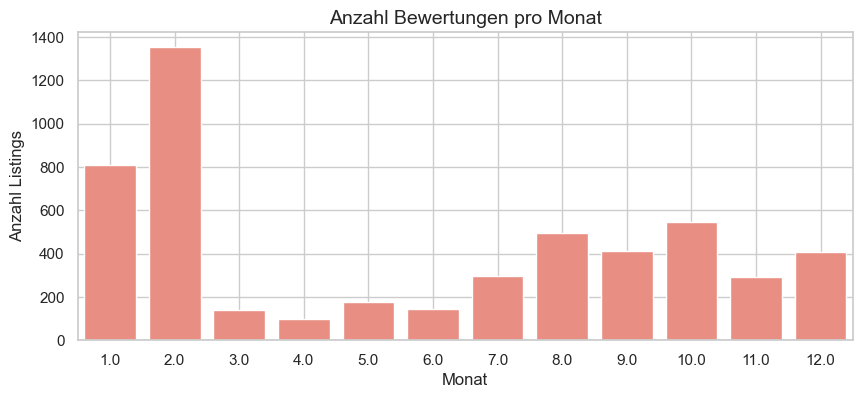

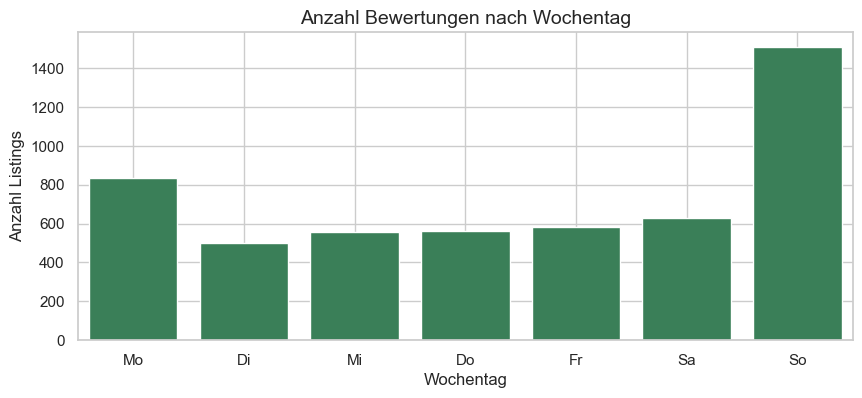

In [17]:
# Plot: Monat der letzten Bewertung
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="review_month", color="salmon")
plt.title("Anzahl Bewertungen pro Monat", fontsize=14)
plt.xlabel("Monat")
plt.ylabel("Anzahl Listings")
plt.grid(True)
plt.show()

# Plot: Wochentag der letzten Bewertung
plt.figure(figsize=(10, 4))
weekday_labels = ["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"]
sns.countplot(data=df, x="review_weekday", color="seagreen")
plt.title("Anzahl Bewertungen nach Wochentag", fontsize=14)
plt.xlabel("Wochentag")
plt.ylabel("Anzahl Listings")
plt.xticks(ticks=range(7), labels=weekday_labels)
plt.grid(True)
plt.show()

In [18]:
# Tage seit letzter Bewertung
heute = pd.to_datetime("today")
df["days_since_last_review"] = (heute - df["last_review"]).dt.days

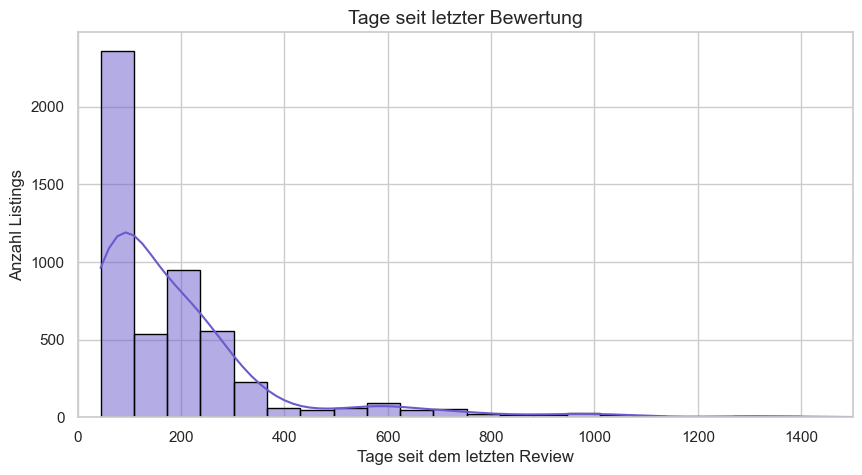

In [19]:
# Plot
plt.figure(figsize=(10, 5))
sns.histplot(
    df["days_since_last_review"].dropna(), bins=50, color="slateblue", edgecolor="black", kde=True
)
plt.xlim(0, 1500)
plt.title("Tage seit letzter Bewertung", fontsize=14)
plt.xlabel("Tage seit dem letzten Review")
plt.ylabel("Anzahl Listings")
plt.grid(True)
plt.show()

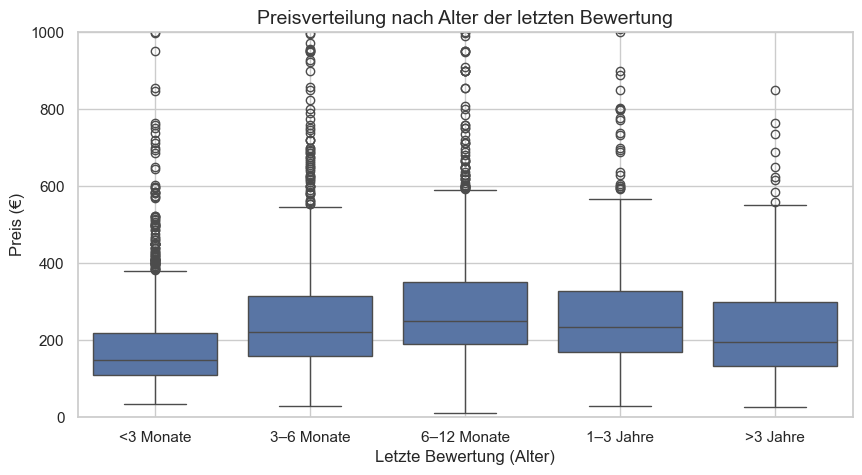

In [20]:
# Gruppiere Listings nach Altersklassen basierend auf Tagen seit letzter Bewertung
df["review_age_group"] = pd.cut(
    df["days_since_last_review"],
    bins=[-1, 90, 180, 365, 1000, df["days_since_last_review"].max()],
    labels=["<3 Monate", "3–6 Monate", "6–12 Monate", "1–3 Jahre", ">3 Jahre"],
)

# Boxplot: Preisverteilung nach Alter der letzten Bewertung
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="review_age_group", y="price")
plt.title("Preisverteilung nach Alter der letzten Bewertung", fontsize=14)
plt.xlabel("Letzte Bewertung (Alter)", fontsize=12)
plt.ylabel("Preis (€)", fontsize=12)
plt.ylim(0, 1000)
plt.grid(True)
plt.show()

In [21]:
# ----------------------------------------------
# Mathematische Funktionen für Winkel & Geometrie
# ----------------------------------------------
from math import atan2, cos, radians, sin, sqrt

# -------------------------------------------------------
# Definition des Stadtzentrums – hier: Dam-Platz Amsterdam
# Diese Koordinaten dienen als Referenzpunkt für Entfernungen
# -------------------------------------------------------
CENTER_LAT = 52.3731  # Breitengrad des Stadtzentrums
CENTER_LONG = 4.8922  # Längengrad des Stadtzentrums


# -------------------------------------------------------
# Funktion zur Berechnung der Entfernung zwischen zwei Punkten auf einer Kugel (Erde)
# Die Haversine-Formel berücksichtigt dabei die Erdkrümmung
# -------------------------------------------------------
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Radius der Erde in Kilometern (konstante Annahme)

    # Umwandlung der Winkelunterschiede von Grad zu Bogenmaß (radians),
    # da trigonometrische Funktionen mit Bogenmaß arbeiten
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    # Anwendung der Haversine-Formel:
    # 'a' beschreibt das quadratische "Abstandsmaß" über Breitengrad- und Längengrad-Winkel
    a = sin(dlat / 2) ** 2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2) ** 2

    # 'c' ist der zentrale Winkel (Great-circle distance) zwischen zwei Punkten auf einer Kugel
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    # Rückgabe der Distanz in Kilometern
    return R * c


# -------------------------------------------------------
# Anwenden der obigen Funktion auf jeden Eintrag im DataFrame
# Dabei wird für jedes Airbnb-Listing die Entfernung zum Stadtzentrum berechnet
# -------------------------------------------------------
df["distance_to_center_km"] = df.apply(
    lambda row: haversine_distance(
        row["latitude"],  # Breitengrad des Listings
        row["longitude"],  # Längengrad des Listings
        CENTER_LAT,  # Breitengrad des Stadtzentrums
        CENTER_LONG,  # Längengrad des Stadtzentrums
    ),
    axis=1,  # axis=1: Zeilenweise Anwendung (jede Zeile ist ein Listing)
)

# -------------------------------------------------------
# Ausgabe der neu berechneten Entfernungen zusammen mit den Koordinaten
# -------------------------------------------------------
df[["latitude", "longitude", "distance_to_center_km"]].head()

,latitude,longitude,distance_to_center_km
0,52.36435,4.94358,3.621494
2,52.36775,4.89092,0.601206
3,52.36584,4.89111,0.810660
6,52.38028,4.89089,0.803317
7,52.37118,4.93146,2.673815


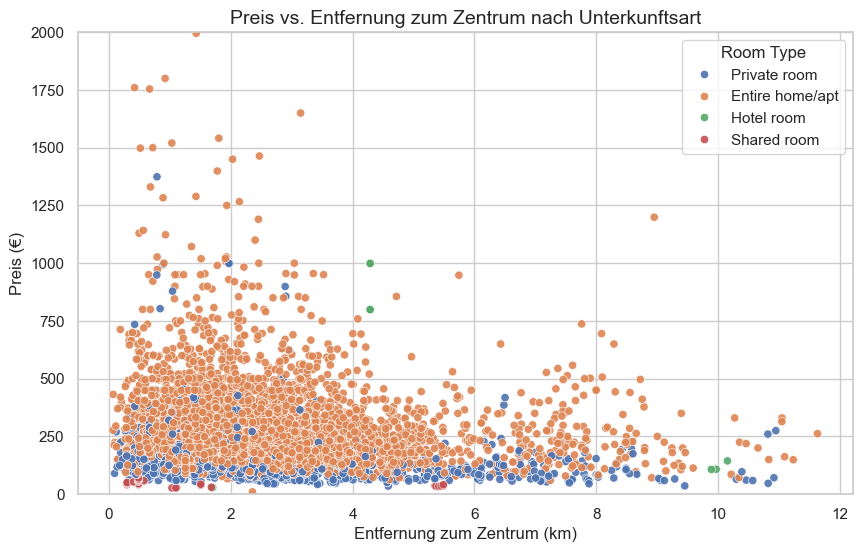

In [22]:
# Scatterplot: Preis vs. Entfernung zum Zentrum mit Zusatzparameter: room_type (Farbkodierung)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="distance_to_center_km", y="price", hue="room_type", alpha=0.9)
plt.title("Preis vs. Entfernung zum Zentrum nach Unterkunftsart", fontsize=14)
plt.xlabel("Entfernung zum Zentrum (km)", fontsize=12)
plt.ylabel("Preis (€)", fontsize=12)
plt.ylim(0, 2000)
plt.legend(title="Room Type")
plt.grid(True)
plt.show()

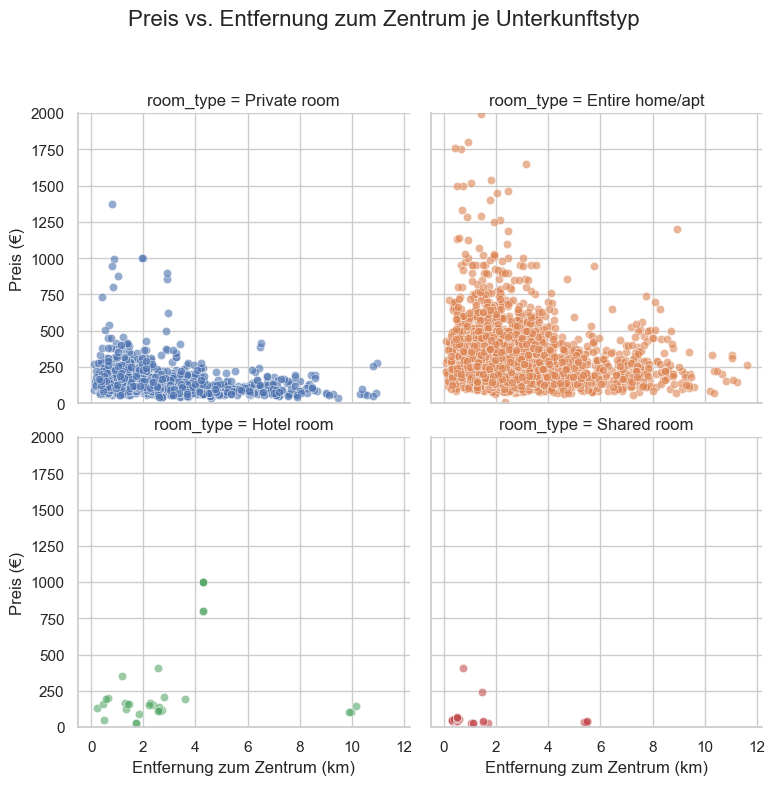

In [23]:
# ---------------------------------------------------------------
# Scatterplot (Punktediagramm) für jeden Unterkunftstyp separat
# Ziel: Preis und Entfernung zum Zentrum in Beziehung setzen,
#       getrennt nach 'room_type' (z. B. Entire home, Private room)
# ---------------------------------------------------------------

# Initialisierung eines FacetGrid – das ist ein Raster aus mehreren Plots
g = sns.FacetGrid(
    df,  # Datensatz, auf dem geplottet wird
    col="room_type",  # Jede Spalte (Facet) zeigt einen room_type (z. B. "Entire home")
    col_wrap=2,  # Maximal 2 Plots pro Zeile (danach Umbruch)
    height=4,  # Höhe jedes einzelnen Plots in Zoll
    sharex=True,  # Alle Plots teilen sich dieselbe X-Achse (Entfernung)
    sharey=True,  # Alle Plots teilen sich dieselbe Y-Achse (Preis)
    hue="room_type",  # Farbkodierung ebenfalls nach Unterkunftstyp (optional hier, da nur 1 Typ pro Plot)
)

# Zeichnet einen Scatterplot in jedes Subplot-Fenster
# X-Achse: Entfernung zum Zentrum (km), Y-Achse: Preis (€)
# Transparenz (alpha) hilft bei überlappenden Punkten
g.map_dataframe(sns.scatterplot, x="distance_to_center_km", y="price", alpha=0.6)

# Achsenbeschriftungen festlegen – gilt für alle Subplots
g.set_axis_labels("Entfernung zum Zentrum (km)", "Preis (€)")

# Leichten Abstand nach oben hinzufügen, damit der Titel nicht überlappt
g.fig.subplots_adjust(top=0.85)

# Supertitel: Überschrift über allen Facet-Plots
g.fig.suptitle("Preis vs. Entfernung zum Zentrum je Unterkunftstyp", fontsize=16)

# Y-Achse für alle Plots begrenzen, um Extremwerte (> 2000 €) auszublenden
plt.ylim(0, 2000)

# Darstellung aller Plots
plt.show()

### **3. Feature Transformation (Transformation)**
- **Preis**: Eine **Log-Transformation** hilft, die rechtsschiefe Verteilung des Preises zu reduzieren, indem wir den logarithmierten Preis (`price_log`) erstellen.
- **Verfügbarkeit (`availability_365`)**: Standardisierung dieser Variablen, um unterschiedliche Skalen bei der Modellierung zu vermeiden.


In [25]:
# Numerische Transformation: Log-Transformation (z.B. "price_log")
#     Glättet stark rechtsschiefe Verteilungen.
df["price_log"] = np.log1p(df["price"])  # log(1 + price)

In [26]:
# Verfügbarkeitsverhältnis
df["availability_ratio"] = df["availability_365"] / 365

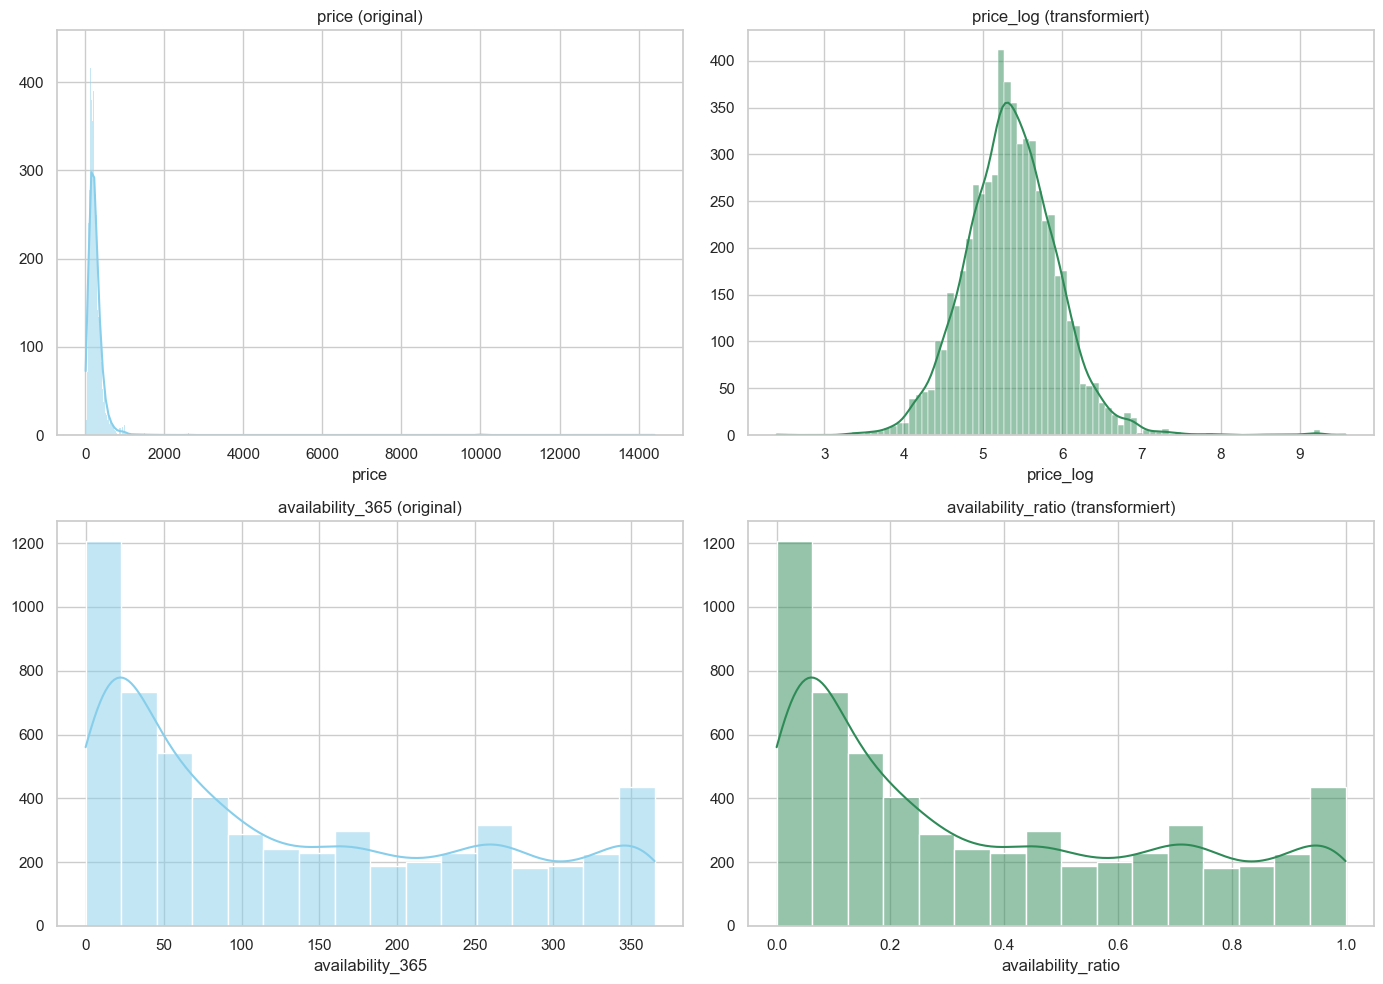

In [27]:
# Variablenpaarungen für nebeneinander-Darstellung
pairs = [("price", "price_log"), ("availability_365", "availability_ratio")]

# Plotting
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

for i, (col_orig, col_z) in enumerate(pairs):
    sns.histplot(data=df, x=col_orig, ax=axes[i, 0], kde=True, color="skyblue")
    axes[i, 0].set_title(f"{col_orig} (original)")
    axes[i, 0].set_ylabel("")

    sns.histplot(data=df, x=col_z, ax=axes[i, 1], kde=True, color="seagreen")
    axes[i, 1].set_title(f"{col_z} (transformiert)")
    axes[i, 1].set_ylabel("")

plt.tight_layout()
plt.show()


### **4. Feature Creation (Erstellung)**

- **`price_per_review`**: Ein neuer Feature, der den Preis im Verhältnis zur durchschnittlichen Bewertung pro Monat setzt, gibt Aufschluss darüber, wie der Preis pro Bewertungseinheit variiert.
- **Binning für Reviews (`reviews_bin`)**: Eine Kategorisierung der Anzahl der Bewertungen (z. B. „wenig“, „mittel“, „viele“) hilft, unterschiedliche Bewertungsarten zu gruppieren und erleichtert die Analyse von Preisunterschieden nach Bewertungshäufigkeit.


In [29]:
# Feature: Preis pro Bewertung
df["room_price_per_review"] = df["price"] / (df["number_of_reviews"] + 1)

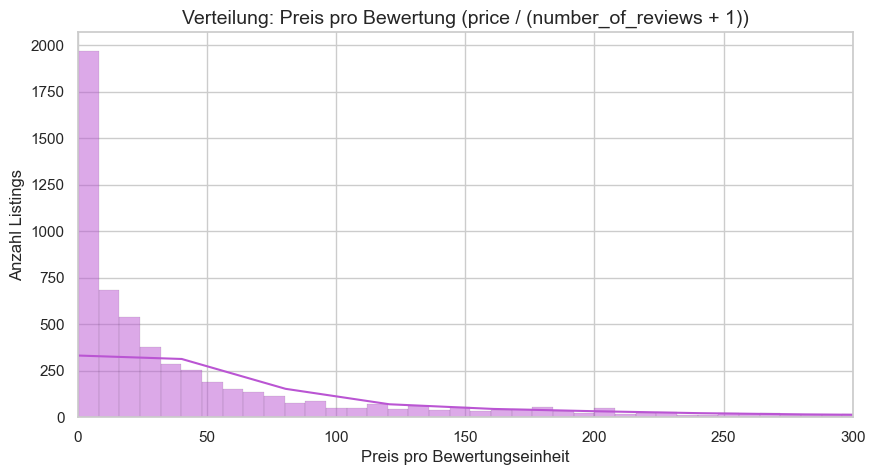

In [30]:
# Feature berechnen: Preis pro Bewertung

# Plot: Histogramm der Verteilung (ggf. begrenzen für bessere Sichtbarkeit)
plt.figure(figsize=(10, 5))
sns.histplot(
    df["room_price_per_review"], bins=1000, color="mediumorchid", edgecolor="black", kde=True
)
plt.title("Verteilung: Preis pro Bewertung (price / (number_of_reviews + 1))", fontsize=14)
plt.xlabel("Preis pro Bewertungseinheit", fontsize=12)
plt.ylabel("Anzahl Listings", fontsize=12)
plt.xlim(0, 300)  # Fokus auf sinnvolleren Wertebereich
plt.grid(True)
plt.show()

#### 🔍 Was ist **„Preis pro Bewertung“**?

Das Feature hat keinen direkten „realen“ Entsprechungswert wie z. B. der Preis – aber es liefert einen **maßgeblichen strukturellen Indikator**, nämlich:

> **Wie viel kostet ein Listing im Verhältnis zu seinem sozialen Vertrauenswert?**

Denn:
- Viele Bewertungen → hohes Vertrauen, etabliertes Angebot
- Wenige Bewertungen → geringeres Vertrauen, möglicherweise neues Angebot

#### 📈 Warum ist das sinnvoll?

##### 1. **Bewertung als soziales Kapital**
- In Plattformen wie Airbnb wirken Bewertungen als **Vertrauenssignale**.
- Je mehr Bewertungen ein Listing hat, desto **beliebter oder zuverlässiger** erscheint es potenziellen Gästen.

##### 2. **Preisbewertung im Kontext**
- Ein Angebot, das **teuer aber stark bewertet** ist, erscheint **wertiger** als eines, das teuer aber kaum bewertet ist.
- Dieses Feature erlaubt es, Listings hinsichtlich ihres **Verhältnisses von Preis zu Erfahrungswert** zu bewerten.

#### 📊 Interpretation

| Preis (€) | Anzahl Bewertungen | Preis pro Bewertung | Bedeutung                          |
|-----------|--------------------|---------------------|-------------------------------------|
| 150       | 50                 | 3.00                | Sehr günstig pro Bewertung → beliebt und günstig |
| 150       | 2                  | 75.00               | Teuer für wenig soziale Bestätigung |
| 80        | 200                | 0.40                | Extrem gutes Preis-Vertrauen-Verhältnis |
| 500       | 5                  | 100              | Hochpreisig + kaum Bewertungen → skeptisch |


#### 📌 Verwendungsmöglichkeiten

#### 📈 Für **analytische Vergleiche**:
- Listings mit ähnlichem Preis, aber unterschiedlichen Bewertungshistorien lassen sich besser beurteilen.
- Gibt Hinweise auf **Über-/Unterbewertung**.

#### 🧠 Für **Modellierung & Features**:
- Gutes Feature zur Vorhersage von **Beliebtheit**, **Nutzervertrauen**, **Conversion Rates**.
- In Clustering oder Regressionsmodellen kann es zur besseren Gruppierung oder Preisvorhersage beitragen.

#### 💡 Einschränkungen & Hinweise

- Ein **neues Listing** mit gutem Preis, aber ohne Bewertung wirkt fälschlich „schlecht“.
  - Lösung: zusätzliche Features einbeziehen wie `days_since_last_review` oder `host_experience_level`.
- Hohe Bewertung bedeutet nicht automatisch hohe Qualität – aber oft hohe **Sichtbarkeit und Nachfrage**.

#### ✅ Fazit

Das Feature **`price_per_review`** ist ein **einfaches, aber wirkungsvolles Verhältnismerkmal**, das:

- **soziale Beliebtheit (Reviews)** und  
- **wirtschaftliche Attraktivität (Preis)**

miteinander in Beziehung setzt. Es ist besonders dann hilfreich, wenn du Listings **nach „Vertrauen pro Preis“** oder **nach Marktrelevanz** bewerten möchtest – gerade wenn `review_scores_rating` fehlt oder unvollständig ist.


In [32]:
# Binning aus Reviews als Stellvertreter für "rating_cat" (falls kein echtes Rating)
#     Beispiel: Low, Mid, High, Ultra
bins = [0, 10, 50, 200, np.inf]
labels = ["Low", "Mid", "High", "Ultra"]
df["rating_cat"] = pd.cut(df["number_of_reviews"], bins=bins, labels=labels)

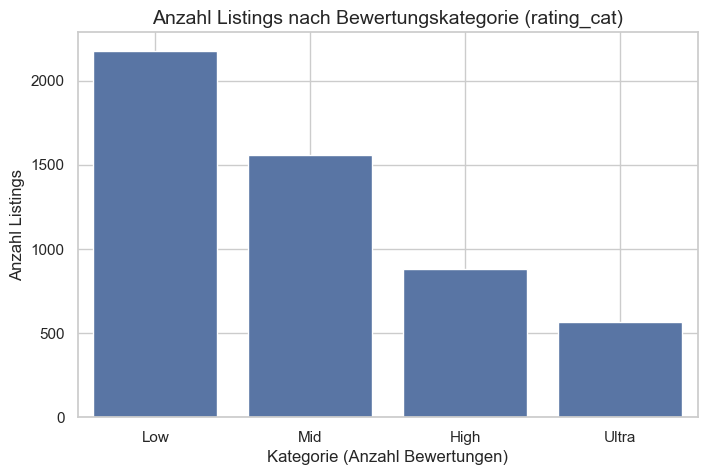

In [33]:
# Visualisierung: Anzahl Listings je Bewertungs-Kategorie
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="rating_cat", order=labels)
plt.title("Anzahl Listings nach Bewertungskategorie (rating_cat)", fontsize=14)
plt.xlabel("Kategorie (Anzahl Bewertungen)", fontsize=12)
plt.ylabel("Anzahl Listings", fontsize=12)
plt.grid(True)
plt.show()

# Für Visualisierung: Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="rating_cat", y="price", order=labels)
plt.title("Preisverteilung nach Bewertungskategorie", fontsize=14)
plt.ylim(0,2000)
plt.xlabel("Bewertungskategorie (rating_cat)", fontsize=12)
plt.ylabel("Preis (€)", fontsize=12)
plt.grid(True)
plt.show()

In [35]:
# Feature : Hat Lizenz?
df["has_license"] = df["license"].notnull().astype(int)

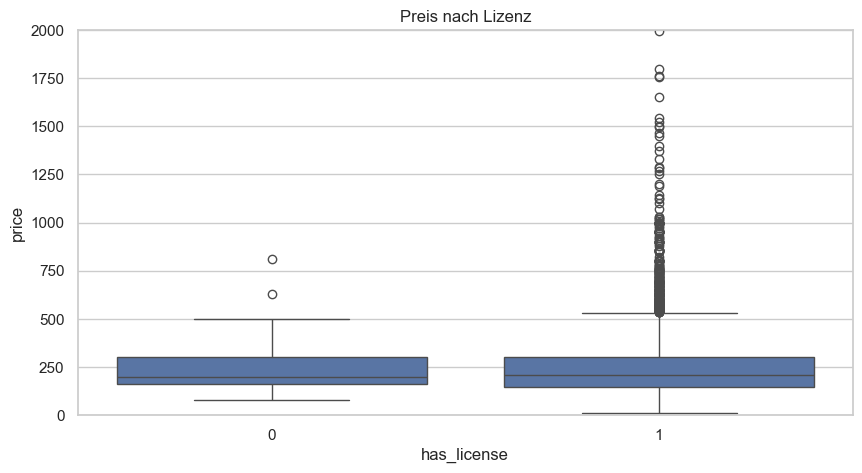

In [36]:
#  license vs. price
sns.boxplot(x="has_license", y="price", data=df)
plt.ylim(0, 2000)
plt.title("Preis nach Lizenz")
plt.show()

In [37]:
# ----------------------------------------
# Ziel: Erzeuge ein neues Feature, das Host-Erfahrung kategorisiert
# Quelle der Information: Anzahl der Listings, die ein Host anbietet
# Annahme: Je mehr Listings, desto erfahrener der Host
# ----------------------------------------

# Definiere Schwellenwerte für Erfahrungsstufen:
# 0 Listings (evtl. Test oder inaktiv), 1, 2–3, 4–10, >10 Listings
experience_bins = [0, 1, 3, 10, np.inf]  # Grenzen für die Erfahrungskategorien

# Benenne jede Erfahrungsstufe passend:
experience_labels = ["Neu", "Einsteiger", "Erfahren", "Profi"]

# ----------------------------------------
# Erstelle eine neue Spalte im DataFrame: 'host_experience_level'
# Nutze pd.cut() zur Einteilung der numerischen Variable
# ----------------------------------------
df["host_experience_level"] = pd.cut(
    df["calculated_host_listings_count"],  # numerische Variable: Anzahl Listings pro Host
    bins=experience_bins,  # Schwellenwerte für die Gruppen
    labels=experience_labels,  # Namen der Gruppen
)

# Ergebnis: Jede Zeile (Listing) bekommt eine von 4 Erfahrungsstufen zugewiesen
# z. B.:
#  - 1 Listing → "Einsteiger"
#  - 5 Listings → "Erfahren"
#  - 20 Listings → "Profi"

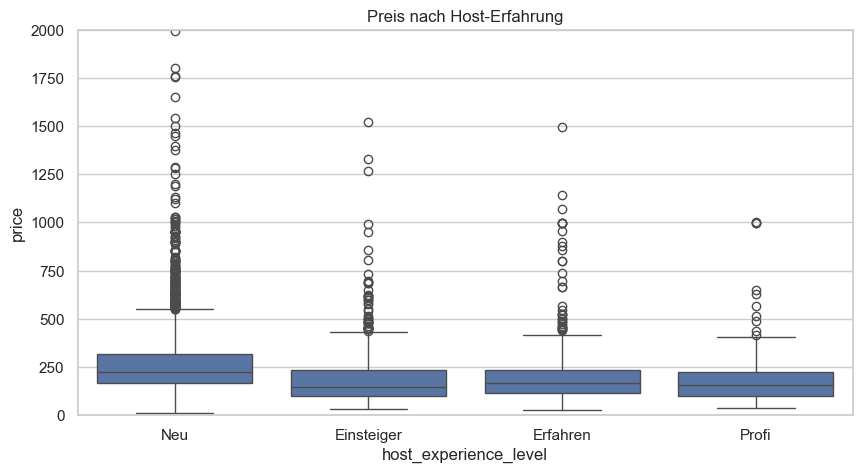

In [38]:
#  host_experience_level vs. price
sns.boxplot(x="host_experience_level", y="price", data=df)
plt.ylim(0, 2000)
plt.title("Preis nach Host-Erfahrung")
plt.show()

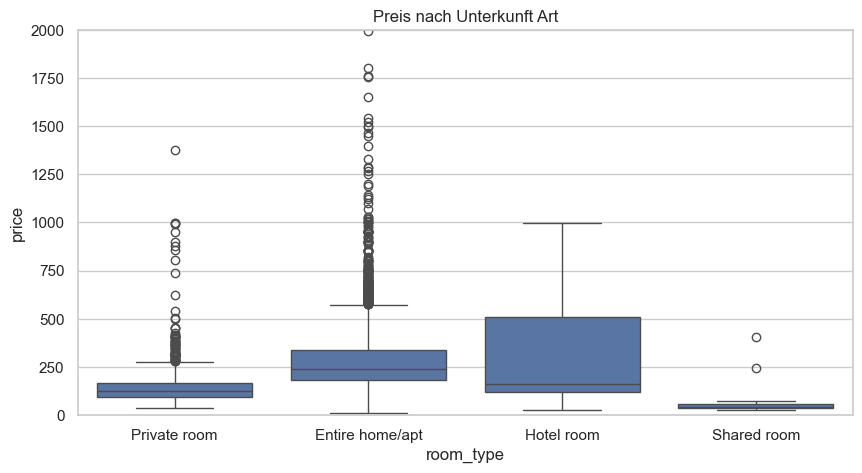

In [39]:
#  room_type vs. price
sns.boxplot(x="room_type", y="price", data=df)
plt.ylim(0, 2000)
plt.title("Preis nach Unterkunft Art")
plt.show()

In [40]:
display(df)

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,...,review_weekday,days_since_last_review,review_age_group,distance_to_center_km,price_log,availability_ratio,room_price_per_review,rating_cat,has_license,host_experience_level
0,2818,Quiet Garden View Room & Super Fast Wi-Fi,3159,Daniel,Oostelijk Havengebied - Indische Buurt,52.364350,4.943580,Private room,66.0,3,...,4.0,102.0,3–6 Monate,3.621494,4.204693,0.027397,0.165414,Ultra,1,Neu
2,28871,Comfortable double room,124245,Edwin,Centrum-West,52.367750,4.890920,Private room,75.0,2,...,4.0,46.0,<3 Monate,0.601206,4.330733,0.230137,0.110619,Ultra,1,Einsteiger
3,29051,Comfortable single room,124245,Edwin,Centrum-Oost,52.365840,4.891110,Private room,59.0,2,...,6.0,44.0,<3 Monate,0.810660,4.094345,0.230137,0.074214,Ultra,1,Einsteiger
6,49552,Multatuli Luxury Guest Suite in top location,225987,Joanna & MP,Centrum-West,52.380280,4.890890,Entire home/apt,259.0,3,...,1.0,63.0,<3 Monate,0.803317,5.560682,0.539726,0.447323,Ultra,1,Neu
7,50263,Cent Adam de Lux 2 bedrooms (4p) apt 125 sqm,230246,Donald,Centrum-Oost,52.371180,4.931460,Entire home/apt,404.0,3,...,6.0,240.0,6–12 Monate,2.673815,6.003887,0.956164,2.419162,High,1,Neu
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10070,1366545843850455084,Spacious luxury apartment in City Center,681505793,Frits,Centrum-Oost,52.363930,4.890370,Entire home/apt,355.0,2,...,NaN,NaN,NaN,1.027199,5.874931,0.158904,355.000000,NaN,0,Neu
10071,1366681723229796790,Cozy appartment in Amsterdam,61554931,Thibault,De Baarsjes - Oud-West,52.370945,4.865289,Entire home/apt,144.0,1,...,NaN,NaN,NaN,1.842587,4.976734,0.073973,144.000000,NaN,1,Neu
10072,1366705754236778230,Bright 1BR Apt w/ 2 Balconies,381452106,Thaiane,Slotervaart,52.355660,4.833230,Entire home/apt,138.0,2,...,NaN,NaN,NaN,4.448941,4.934474,0.279452,138.000000,NaN,1,Neu
10073,1367343921692027564,Ko l k private mini studio,449825081,Dario,Centrum-West,52.375430,4.894620,Entire home/apt,126.0,1,...,NaN,NaN,NaN,0.306778,4.844187,0.013699,126.000000,NaN,1,Erfahren


In [41]:
# Feature: # ----------------------------------------
# Ziel: Kategorische Variable 'room_type' in numerische Spalten umwandeln
# Methode: One-Hot-Encoding mit pandas.get_dummies()
# ----------------------------------------

df = pd.get_dummies(
    df,  # Ursprünglicher DataFrame
    columns=["room_type"],  # Spalte, die umgewandelt werden soll
    drop_first=False,  # Erste Kategorie auslassen, um Redundanz zu vermeiden (Dummy-Variable-Trap) - Um Multikollinearität in linearen Modellen zu vermeiden.
)

display(df)

,id,name,host_id,host_name,neighbourhood,latitude,longitude,price,minimum_nights,number_of_reviews,...,price_log,availability_ratio,room_price_per_review,rating_cat,has_license,host_experience_level,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,2818,Quiet Garden View Room & Super Fast Wi-Fi,3159,Daniel,Oostelijk Havengebied - Indische Buurt,52.364350,4.943580,66.0,3,398,...,4.204693,0.027397,0.165414,Ultra,1,Neu,False,False,True,False
2,28871,Comfortable double room,124245,Edwin,Centrum-West,52.367750,4.890920,75.0,2,677,...,4.330733,0.230137,0.110619,Ultra,1,Einsteiger,False,False,True,False
3,29051,Comfortable single room,124245,Edwin,Centrum-Oost,52.365840,4.891110,59.0,2,794,...,4.094345,0.230137,0.074214,Ultra,1,Einsteiger,False,False,True,False
6,49552,Multatuli Luxury Guest Suite in top location,225987,Joanna & MP,Centrum-West,52.380280,4.890890,259.0,3,578,...,5.560682,0.539726,0.447323,Ultra,1,Neu,True,False,False,False
7,50263,Cent Adam de Lux 2 bedrooms (4p) apt 125 sqm,230246,Donald,Centrum-Oost,52.371180,4.931460,404.0,3,166,...,6.003887,0.956164,2.419162,High,1,Neu,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10070,1366545843850455084,Spacious luxury apartment in City Center,681505793,Frits,Centrum-Oost,52.363930,4.890370,355.0,2,0,...,5.874931,0.158904,355.000000,NaN,0,Neu,True,False,False,False
10071,1366681723229796790,Cozy appartment in Amsterdam,61554931,Thibault,De Baarsjes - Oud-West,52.370945,4.865289,144.0,1,0,...,4.976734,0.073973,144.000000,NaN,1,Neu,True,False,False,False
10072,1366705754236778230,Bright 1BR Apt w/ 2 Balconies,381452106,Thaiane,Slotervaart,52.355660,4.833230,138.0,2,0,...,4.934474,0.279452,138.000000,NaN,1,Neu,True,False,False,False
10073,1367343921692027564,Ko l k private mini studio,449825081,Dario,Centrum-West,52.375430,4.894620,126.0,1,0,...,4.844187,0.013699,126.000000,NaN,1,Erfahren,True,False,False,False


In [42]:
# Label-Encoding (z.B. für 'neighbourhood')
le = LabelEncoder()
df["neighbourhood_label"] = le.fit_transform(df["neighbourhood"])
df["neighbourhood_label"].sample(10)

7133     3
4975     7
2327    19
3025     2
2419     4
9964     5
7667     4
7458     8
45       4
6268    11
Name: neighbourhood_label, dtype: int32

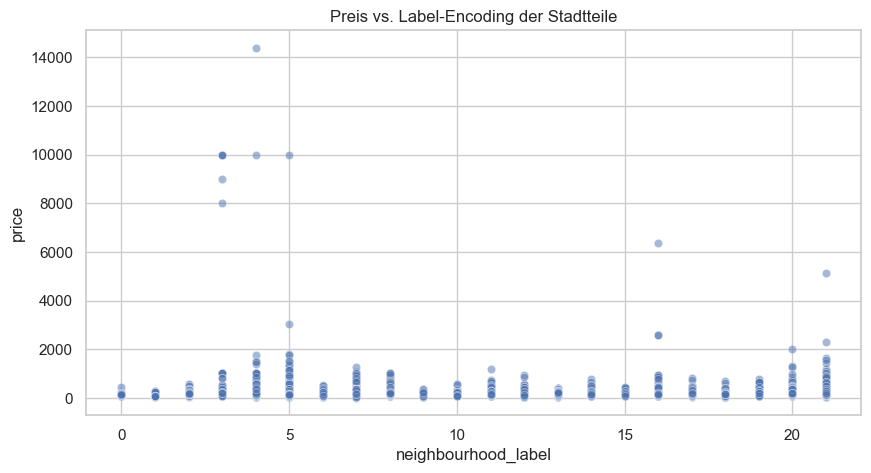

In [43]:
# Label-Encoding: neighbourhood_label
sns.scatterplot(data=df, x="neighbourhood_label", y="price", alpha=0.5)
plt.title("Preis vs. Label-Encoding der Stadtteile")
plt.show()

#### 💡 Warum machen wir das?

Viele Machine-Learning-Modelle können mit Texten wie `"Oud-West"` oder `"Centrum-West"` **nichts anfangen**.  
Sie brauchen Zahlen. Also geben wir jedem Viertel einfach eine eindeutige Nummer, bspw.:

| `neighbourhood`  | `neighbourhood_encoded` |
|------------------|--------------------------|
| Centrum-West     | 0                        |
| De Pijp          | 1                        |
| Oud-West         | 2                        |
| Jordaan          | 3                        |
| …                | …                        |

Das Ganze ist **keine Bewertung oder Rangfolge**, sondern einfach nur eine **ID**.


##### ⚠️ Achtung, Denkfalle!

Label Encoding **suggeriert eine Reihenfolge**, obwohl keine da ist!  
Ein Modell könnte denken: *„Aha, Jordaan (3) ist besser als De Pijp (1)“* – aber das stimmt natürlich nicht (außer man wohnt da 😉).  
Deshalb ist **One-Hot-Encoding** oft besser für solche **nominalen Kategorien** – also wenn es **keine natürliche Reihenfolge** gibt.


##### 📦 Wann ist Label Encoding trotzdem okay?

- Wenn du **viele Kategorien** hast, ist One-Hot-Encoding vielleicht zu aufgeblasen.
- Bei Modellen wie **Tree-based Algorithmen** (z. B. Random Forest, XGBoost) ist Label Encoding meist kein Problem, weil sie die Werte **nicht als echte Zahlen behandeln**, sondern **nur splitten**. Dazu aber im ML Modul mehr!


##### 🎯 Fazit:

Label Encoding macht aus Nachbarschaften **maschinell lesbare IDs**, ist also eine schnelle Lösung.  
Aber: Nicht überall passt sie perfekt – **Kontext entscheidet**!


✅ Der  **Airbnb-Datensatz wurde bereinigt, transformiert und erweitert**!


## 📦 Zusammenfassung der durchgeführten Schritte:

### 🔧 **Datenbereinigung**
- Fehlende Preise entfernt
- Leere Spalten entfernt

### 🧠 **Feature Engineering**
- **`last_review`** als Datum erkannt
- **`price_log`**: logarithmierter Preis
- **`room_price_per_review`**: Preis im Verhältnis zu Anzahl Bewertungen
- **`availability_ratio`**: standardisierte Kennzahlen
- **`distance_to_center_km`**: Entfernung zum Dam-Platz (Zentrum von Amsterdam)
- **`review_year`, `review_month`, `review_weekday`**: Zeitmerkmale aus `last_review`
- **`days_since_last_review`**: wie lange es her ist, seit das Listing zuletzt bewertet wurde
- **`rating_cat`**: Kategorien nach Anzahl Bewertungen (Low–Ultra)
- **`host_experience_level`**: Host-Klassifikation basierend auf Anzahl Listings
- **`neighbourhood_encoded`**: Label-Encoding der Nachbarschaften
- **Dummy-Variablen für `room_type`**: z. B. `room_type_Private room`

